# Detección de fraude por voz con deepfakes

Este notebook sigue el flujo usado para clasificar audios reales y audios fake usando embeddings de wav2vec. primero se preparan las tablas en databricks. luego se arman las variables del modelo. después se balancea el entrenamiento. finalmente se entrenan y comparan tres modelos.


## Paso 1. crear la base de datos y el volumen

aquí se crea el espacio de trabajo donde van a quedar guardados los datos y las tablas del proyecto.


In [0]:
%sql
-- se crea la base si todavía no existe
CREATE DATABASE IF NOT EXISTS deepfake_bd;


In [0]:
%sql
-- se crea el volumen donde están los archivos parquet
CREATE VOLUME IF NOT EXISTS deepfake_bd.data;


In [0]:
%python
# revisamos qué archivos hay dentro del volumen
# esto ayuda a confirmar que los parquet sí están cargados
dbutils.fs.ls("/Volumes/workspace/deepfake_bd/data")


[FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/ASVspoof2019_test_wav2vec.parquet', name='ASVspoof2019_test_wav2vec.parquet', size=138296596, modificationTime=1777211159000),
 FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/ASVspoof2019_train_wav2vec.parquet', name='ASVspoof2019_train_wav2vec.parquet', size=554945423, modificationTime=1777211158000),
 FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/ASVspoof2021_test_wav2vec.parquet', name='ASVspoof2021_test_wav2vec.parquet', size=447171926, modificationTime=1777217540000),
 FileInfo(path='dbfs:/Volumes/workspace/deepfake_bd/data/ASVspoof2021_train_wav2vec.parquet', name='ASVspoof2021_train_wav2vec.parquet', size=1782958009, modificationTime=1777217540000)]

## Paso 2. cargar los datos parquet

Se cargan los archivos de entrenamiento y prueba; estos archivos ya tienen los embeddings de audio generados con wav2vec.


In [0]:
# cargamos una muestra del parquet de entrenamiento
df = spark.read.parquet("/Volumes/workspace/deepfake_bd/data/ASVspoof2021_train_wav2vec.parquet")
display(df.limit(5))


emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,emb_39,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49,emb_50,emb_51,emb_52,emb_53,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,emb_64,emb_65,emb_66,emb_67,emb_68,emb_69,emb_70,emb_71,emb_72,emb_73,emb_74,emb_75,emb_76,emb_77,emb_78,emb_79,emb_80,emb_81,emb_82,emb_83,emb_84,emb_85,emb_86,emb_87,emb_88,emb_89,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99,emb_100,emb_101,emb_102,emb_103,emb_104,emb_105,emb_106,emb_107,emb_108,emb_109,emb_110,emb_111,emb_112,emb_113,emb_114,emb_115,emb_116,emb_117,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,emb_128,emb_129,emb_130,emb_131,emb_132,emb_133,emb_134,emb_135,emb_136,emb_137,emb_138,emb_139,emb_140,emb_141,emb_142,emb_143,emb_144,emb_145,emb_146,emb_147,emb_148,emb_149,emb_150,emb_151,emb_152,emb_153,emb_154,emb_155,emb_156,emb_157,emb_158,emb_159,emb_160,emb_161,emb_162,emb_163,emb_164,emb_165,emb_166,emb_167,emb_168,emb_169,emb_170,emb_171,emb_172,emb_173,emb_174,emb_175,emb_176,emb_177,emb_178,emb_179,emb_180,emb_181,emb_182,emb_183,emb_184,emb_185,emb_186,emb_187,emb_188,emb_189,emb_190,emb_191,emb_192,emb_193,emb_194,emb_195,emb_196,emb_197,emb_198,emb_199,emb_200,emb_201,emb_202,emb_203,emb_204,emb_205,emb_206,emb_207,emb_208,emb_209,emb_210,emb_211,emb_212,emb_213,emb_214,emb_215,emb_216,emb_217,emb_218,emb_219,emb_220,emb_221,emb_222,emb_223,emb_224,emb_225,emb_226,emb_227,emb_228,emb_229,emb_230,emb_231,emb_232,emb_233,emb_234,emb_235,emb_236,emb_237,emb_238,emb_239,emb_240,emb_241,emb_242,emb_243,emb_244,emb_245,emb_246,emb_247,emb_248,emb_249,emb_250,emb_251,emb_252,emb_253,emb_254,emb_255,emb_256,emb_257,emb_258,emb_259,emb_260,emb_261,emb_262,emb_263,emb_264,emb_265,emb_266,emb_267,emb_268,emb_269,emb_270,emb_271,emb_272,emb_273,emb_274,emb_275,emb_276,emb_277,emb_278,emb_279,emb_280,emb_281,emb_282,emb_283,emb_284,emb_285,emb_286,emb_287,emb_288,emb_289,emb_290,emb_291,emb_292,emb_293,emb_294,emb_295,emb_296,emb_297,emb_298,emb_299,emb_300,emb_301,emb_302,emb_303,emb_304,emb_305,emb_306,emb_307,emb_308,emb_309,emb_310,emb_311,emb_312,emb_313,emb_314,emb_315,emb_316,emb_317,emb_318,emb_319,emb_320,emb_321,emb_322,emb_323,emb_324,emb_325,emb_326,emb_327,emb_328,emb_329,emb_330,emb_331,emb_332,emb_333,emb_334,emb_335,emb_336,emb_337,emb_338,emb_339,emb_340,emb_341,emb_342,emb_343,emb_344,emb_345,emb_346,emb_347,emb_348,emb_349,emb_350,emb_351,emb_352,emb_353,emb_354,emb_355,emb_356,emb_357,emb_358,emb_359,emb_360,emb_361,emb_362,emb_363,emb_364,emb_365,emb_366,emb_367,emb_368,emb_369,emb_370,emb_371,emb_372,emb_373,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,emb_384,emb_385,emb_386,emb_387,emb_388,emb_389,emb_390,emb_391,emb_392,emb_393,emb_394,emb_395,emb_396,emb_397,emb_398,emb_399,emb_400,emb_401,emb_402,emb_403,emb_404,emb_405,emb_406,emb_407,emb_408,emb_409,emb_410,emb_411,emb_412,emb_413,emb_414,emb_415,emb_416,emb_417,emb_418,emb_419,emb_420,emb_421,emb_422,emb_423,emb_424,emb_425,emb_426,emb_427,emb_428,emb_429,emb_430,emb_431,emb_432,emb_433,emb_434,emb_435,emb_436,emb_437,emb_438,emb_439,emb_440,emb_441,emb_442,emb_443,emb_444,emb_445,emb_446,emb_447,emb_448,emb_449,emb_450,emb_451,emb_452,emb_453,emb_454,emb_455,emb_456,emb_457,emb_458,emb_459,emb_460,emb_461,emb_462,emb_463,emb_464,emb_465,emb_466,emb_467,emb_468,emb_469,emb_470,emb_471,emb_472,emb_473,emb_474,emb_475,emb_476,emb_477,emb_478,emb_479,emb_480,emb_481,emb_482,emb_483,emb_484,emb_485,emb_486,emb_487,emb_488,emb_489,emb_490,emb_491,emb_492,emb_493,emb_494,emb_495,emb_496,emb_497,emb_498,emb_499,emb_500,emb_501,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,emb_512,emb_51

In [0]:
# leemos el conjunto de entrenamiento desde el volumen
df_train = spark.read.parquet("/Volumes/workspace/deepfake_bd/data/ASVspoof2021_train_wav2vec.parquet")
df_train.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_train")


In [0]:
# hacemos lo mismo con el conjunto de prueba
# esta tabla se usará al final para evaluar los modelos
df_test = spark.read.parquet("/Volumes/workspace/deepfake_bd/data/ASVspoof2021_test_wav2vec.parquet")
df_test.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_test")


## Paso 3. Construir la variable features

Los embeddings vienen separados en muchas columnas. Spark necesita que esas columnas estén juntas en un solo vector llamado features.


In [0]:
from pyspark.ml.feature import VectorAssembler

# cargamos la tabla de entrenamiento que ya quedó guardada
df_train = spark.table("deepfake_bd.deepfake_train")

# nos quedamos con todas las columnas que empiezan con emb_
# esas columnas son los valores del embedding de cada audio
emb_cols = [c for c in df_train.columns if c.startswith("emb_")]

# vectorassembler junta todas las columnas numéricas en un solo vector
assembler = VectorAssembler(
    inputCols=emb_cols,
    outputCol="features"
)

# se arma el vector de variables y se deja solo lo necesario para modelar
df_train_w = assembler.transform(df_train)
df_train_w = df_train_w.select("features", "label")

display(df_train_w.limit(5))


features label {"type":"1","size":null,"indices":null,"values":["-0.029589055106043816","-0.0254713986068964","-0.06821349263191223","-0.059604495763778687","0.10021186619997025","-0.09315326809883118","-0.019123850390315056","-0.03005377948284149","0.023983249440789223","-0.2199363112449646","0.010387806221842766","-0.0441286675632","0.05312675982713699","0.010382775217294693","-0.13182345032691956","-0.02761448360979557","-0.4019557237625122","0.3119756281375885","0.016660910099744797","0.16017203032970428","-0.1759006679058075","0.03850068151950836","0.2103329598903656","0.035057954490184784","0.0481632798910141","-0.03202162683010101","-0.3630580008029938","0.009525535628199577","0.08103401213884354","-0.19742657244205475","0.1507541388273239","-0.007653691340237856","-0.11869926750659943","-0.07226629555225372","-0.1579173058271408","0.04303700849413872","-0.08795557916164398","-0.16632118821144104","-0.10163853317499161","0.06456221640110016","-0.17161071300506592","-0.06641095131635666","-0.09525934606790543","0.3254006803035736","-0.19771045446395874","-0.06860467046499252","-0.020037800073623657","-0.09493207186460495","-0.007940514013171196","0.01319532934576273","-0.0866268053650856","-0.03848063945770264","0.05753425508737564","0.06487486511468887","0.009811393916606903","2.1657798788510263E-4","0.02525162883102894","-0.4121399223804474","-0.1377049684524536","-0.05956543982028961","-0.1398676335811615","-0.043243397027254105","0.018013905733823776","0.22525347769260406","-0.0646447166800499","0.11252384632825851","2.6576226809993386E-4","0.0072364830411970615","-0.10694428533315659","-0.004945802967995405","-0.011801560409367085","-0.018189799040555954","-0.14994797110557556","-0.07964710891246796","0.02966015413403511","-0.025718698278069496","-0.09324467927217484","-0.02976289950311184","-0.03961416706442833","-0.01776842214167118","-0.06935939192771912","0.04083423316478729","0.030669905245304108","0.010361176915466785","-0.02372930571436882","-0.002990481909364462","-0.16503815352916718","-0.17741389572620392","-0.008290976285934448","0.0066526588052511215","0.38405293226242065","-0.11726967245340347","0.013867739588022232","0.036792900413274765","0.03793879598379135","-0.042042095214128494","-0.02175300195813179","-0.006587387528270483","-0.03716876730322838","-0.04721052572131157","-0.0023366964887827635","-0.2108854204416275","-0.009546914137899876","-0.13112257421016693","0.10914511978626251","0.22246472537517548","0.014316744171082973","0.07248445600271225","0.029366223141551018","0.16083472967147827","-9.083734476007521E-4","0.1418352872133255","-0.05215483531355858","0.03863723576068878","-0.09710019081830978","-0.007004254497587681","0.016953010112047195","-0.15728341042995453","-0.046784017235040665","-0.011308050714433193","0.08527697622776031","0.00941637996584177","0.141840860247612","0.012892485596239567","-0.03440289944410324","-0.17180804908275604","0.08201286941766739","0.2631899416446686","-0.09467463195323944","0.022769881412386894","0.07910658419132233","-0.1063469797372818","-0.017745068296790123","0.0027288771234452724","-0.03542698174715042","-0.029975781217217445","-0.10825493186712265","0.06895630806684494","0.020602835342288017","-0.6763474345207214","0.0013814640697091818","-0.007206686772406101","-0.01048668846487999","0.33322930335998535","0.006929734721779823","-0.041742537170648575","-0.5920228958129883","0.06644803285598755","-0.20385873317718506","-0.0264307651668787","0.010792707093060017","0.1337764412164688","0.2187938541173935","-0.12299073487520218","0.03784825652837753","-0.021774914115667343","0.005114969797432423","0.0016811100067570806","0.32694485783576965","-0.03226915001869202","-0.1816299557685852","0.18851643800735474","0.16648580133914948","-0.009189879521727562","0.08606995642185211","-0.02758457511663437","-0.16943837702274323","-0.2378644496202469","0.3508114218711853","0.18892908096313477","0.025501636788249016","-0.009198155254125595","0.039718564599752426","

In [0]:
# guardamos el entrenamiento ya transformado
# así no tenemos que repetir el armado del vector después
df_train_w.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_train_features")


In [0]:
# aplicamos el mismo assembler al conjunto de prueba
# es importante usar la misma estructura de variables
df_test = spark.table("deepfake_bd.deepfake_test")
df_test_w = assembler.transform(df_test)
df_test_w = df_test_w.select("features", "label")

display(df_test_w.limit(5))


features label {"type":"1","size":null,"indices":null,"values":["-0.03874802216887474","-7.37461494281888E-4","-0.10665831714868546","-0.06294898688793182","0.09748741239309311","-0.05376055836677551","0.04150303825736046","-0.011304649524390697","0.04519692808389664","-0.22483620047569275","-0.026124129071831703","-0.014651568606495857","0.04261235520243645","0.02544984593987465","-0.027543311938643456","0.00269345473498106","-0.36038509011268616","0.2723095715045929","0.018211735412478447","0.046798765659332275","-0.18306508660316467","0.06842199712991714","0.2917213439941406","0.021337002515792847","0.1090741977095604","0.010737631469964981","-0.456484854221344","0.053755953907966614","0.051054902374744415","-0.20233450829982758","0.17101338505744934","-0.0064087179489433765","-0.038789425045251846","-0.08318303525447845","-0.17810708284378052","0.11175686120986938","0.02071462757885456","-0.1649557501077652","-0.08572424948215485","0.04114833101630211","-0.14823488891124725","-0.10824914276599884","-0.17134784162044525","0.17696090042591095","-0.222448468208313","-0.03618815541267395","-0.025188282132148743","-0.014573388732969761","0.03421750292181969","0.020312171429395676","-0.07474123686552048","0.03555244952440262","-0.0700899064540863","0.04458877816796303","0.01236678659915924","-0.09023629873991013","0.012829841114580631","-0.35330817103385925","-0.14375370740890503","-0.06788869947195053","-0.0853625014424324","-0.06373292207717896","0.01766566000878811","0.1457137167453766","-0.047787852585315704","0.09669119119644165","-0.0026444154791533947","-0.05612479895353317","-0.12296374142169952","-0.008470391854643822","0.005724898539483547","-0.02456570602953434","-0.07537920773029327","-0.11833290755748749","0.012500102631747723","-0.03156515210866928","-0.08725900948047638","-0.07932205498218536","-0.033899374306201935","-0.005737184081226587","-0.11928046494722366","0.19720418751239777","0.06566494703292847","0.06894667446613312","-0.02648284286260605","-0.03622179478406906","-0.1177070140838623","-0.21575243771076202","-0.013572515919804573","0.020939398556947708","0.2615255117416382","-0.08234276622533798","0.07509123533964157","0.029271123930811882","0.058612775057554245","-0.06388968974351883","0.16367898881435394","-0.023287435993552208","-0.03737086430191994","-0.07583193480968475","-0.023195406422019005","-0.1504129320383072","0.0398368239402771","-0.10310116410255432","0.12927448749542236","0.11653541028499603","0.049799852073192596","0.08882633596658707","0.019424019381403923","0.08979153633117676","-0.02689620852470398","0.038515787571668625","-0.0807880386710167","0.036539897322654724","-0.10846943408250809","-0.01348296832293272","0.018099253997206688","-0.03163458779454231","-0.0501583032310009","-0.015524263493716717","0.11332853138446808","-2.1779446979053319E-4","0.07509119808673859","4.962183884344995E-4","-0.06090041995048523","-0.06768164783716202","0.026322660967707634","0.23613496124744415","-0.06183967366814613","0.013907395303249359","0.09397581964731216","-0.09572979062795639","0.054814308881759644","-0.0047368248924613","-0.018844056874513626","0.035874105989933014","-0.19154129922389984","0.055918313562870026","0.02158891223371029","-0.7187952995300293","-0.0024491494987159967","-6.805676384828985E-4","-0.0083829490467906","0.24683399498462677","0.02540401928126812","-0.04968656599521637","-0.5281166434288025","0.06913074851036072","-0.14848105609416962","-0.03890456259250641","0.01986590027809143","0.13790363073349","0.29739049077033997","-0.1704249382019043","0.04113892838358879","0.026723423972725868","0.03537783399224281","-0.03408116102218628","0.11923296004533768","-0.0349758118391037","-0.17335310578346252","0.20289354026317596","0.1597030758857727","-0.05042486637830734","0.07397371530532837","-0.04132024198770523","-0.11376132071018219","-0.1898176372051239","0.4122374653816223","0.1849188506603241","0.02923370525240898","0.06843050569295883","0.02766978181898594","0.15646910667419

In [0]:
# guardamos también la prueba transformada
df_test_w.write.mode("overwrite").saveAsTable("deepfake_bd.deepfake_test_features")


## Paso 4. Preparar etiquetas y revisar clases

La variable label viene como texto. Se transforma a 1 para fake y 0 para real. también se revisa el desbalance entre clases.


In [0]:
# cargamos las tablas que ya tienen features y label
df_train = spark.table("deepfake_bd.deepfake_train_features")
df_test = spark.table("deepfake_bd.deepfake_test_features")


In [0]:
from pyspark.sql.functions import when

# convertimos la etiqueta a formato numérico
# fake queda como 1 y real queda como 0
df_train = df_train.withColumn("label", when(df_train.label == "fake", 1).otherwise(0))
df_test = df_test.withColumn("label", when(df_test.label == "fake", 1).otherwise(0))


In [0]:
# contamos cuántos audios hay por clase en entrenamiento
# esto permite ver si el dataset está balanceado o no
df_train.groupBy("label").count().display()


label,count
1,525677
0,24508


## Paso 5. Balancear el entrenamiento

Como hay muchas más muestras fake que reales se aplica undersampling. La idea es bajar la clase mayoritaria para que el modelo no aprenda sesgado.


In [0]:
# separamos las dos clases para poder balancearlas
df_train1 = df_train.filter("label = 1")
df_train0 = df_train.filter("label = 0")


In [0]:
# calculamos qué fracción de la clase fake vamos a tomar
# se usa como referencia la cantidad de audios reales
fraction = df_train0.count() / df_train1.count()

# tomamos una muestra aleatoria de la clase fake
# la semilla ayuda a que el resultado sea reproducible
df_train1_sampled = df_train1.sample(fraction=fraction, seed=42)

# juntamos la muestra fake con todos los reales
df_balanced_train = df_train1_sampled.union(df_train0)


In [0]:
# verificamos que el entrenamiento quedó más balanceado
df_balanced_train.groupBy("label").count().display()


label,count
1,24479
0,24508


## Paso 6. Entrenar los modelos

Se prueban tres modelos. Regresión logística como base. Random forest como ensamble. GBT como modelo más flexible para capturar patrones más complejos.


In [0]:
from pyspark.ml.classification import LogisticRegression

# modelo base lineal
# sirve como primera comparación porque es simple y rápido
lr = LogisticRegression(featuresCol="features", labelCol="label")

# entrenamos con el dataset balanceado
lr_model = lr.fit(df_balanced_train)

# generamos predicciones sobre el test original
lr_pred = lr_model.transform(df_test)


In [0]:
from pyspark.ml.classification import RandomForestClassifier

# random forest combina varios árboles
# esto ayuda a capturar relaciones no lineales entre los embeddings
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,   # cantidad de árboles
    maxDepth=10     # profundidad máxima de cada árbol
)

# entrenamos y predecimos en test
rf_model = rf.fit(df_balanced_train)
rf_pred = rf_model.transform(df_test)


In [0]:
from pyspark.ml.classification import GBTClassifier

# gbt entrena árboles de forma secuencial
# cada árbol intenta corregir errores del anterior
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50,   # número de iteraciones del boosting
    maxDepth=5    # profundidad máxima del árbol
)

# en este bloque se usa el entrenamiento completo
# si se quiere comparar igual que los otros modelos se puede cambiar por df_balanced_train
gbt_model = gbt.fit(df_train)

gbt_pred = gbt_model.transform(df_test)


## Paso 7. Evaluar precision recall y auc

Se calculan métricas para comparar los modelos. En este problema el recall es importante porque interesa detectar la mayor cantidad posible de audios fake.


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# evaluator calcula métricas de clasificación usando las predicciones
evaluator = MulticlassClassificationEvaluator(labelCol="label")

print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(lr_pred))
print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(lr_pred))


Precision: 0.9558057892106553
Recall: 0.838144889757793


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# métricas para random forest
evaluator = MulticlassClassificationEvaluator(labelCol="label")

print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(rf_pred))
print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(rf_pred))


Precision: 0.9547253486257593
Recall: 0.8300206364722494


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# métricas para gbt
evaluator = MulticlassClassificationEvaluator(labelCol="label")

print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(gbt_pred))
print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(gbt_pred))


Precision: 0.9574669096464785
Recall: 0.9630643351073459


In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# auc mide qué tan bien separa el modelo las dos clases
# usa la curva roc como referencia
evaluator = BinaryClassificationEvaluator(labelCol="label")

print("Logistic Regression AUC:", evaluator.evaluate(lr_pred))
print("Random Forest AUC:", evaluator.evaluate(rf_pred))
print("GBT AUC:", evaluator.evaluate(gbt_pred))


Logistic Regression AUC: 0.923737506613815
Random Forest AUC: 0.9186861984658257
GBT AUC: 0.9040412296468452


## Paso 8. Matrices de confusión

Las matrices muestran aciertos y errores por clase... ayudan a ver falsos positivos y falsos negativos.


In [0]:
# agrupamos por etiqueta real y predicción
# luego pasamos a pandas para graficar con seaborn
cm_lr = lr_pred.groupBy("label", "prediction").count().toPandas()
cm_rf = rf_pred.groupBy("label", "prediction").count().toPandas()
cm_gbt = gbt_pred.groupBy("label", "prediction").count().toPandas()


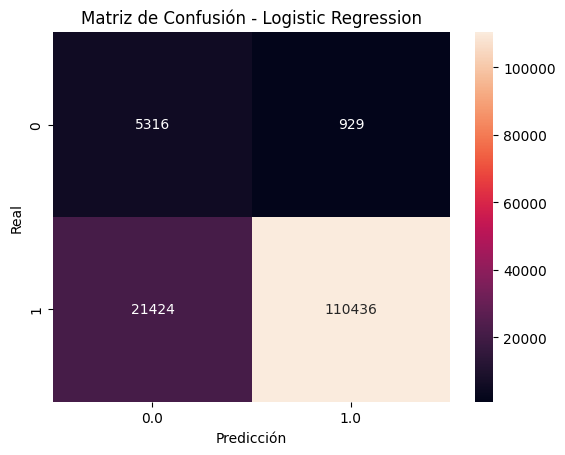

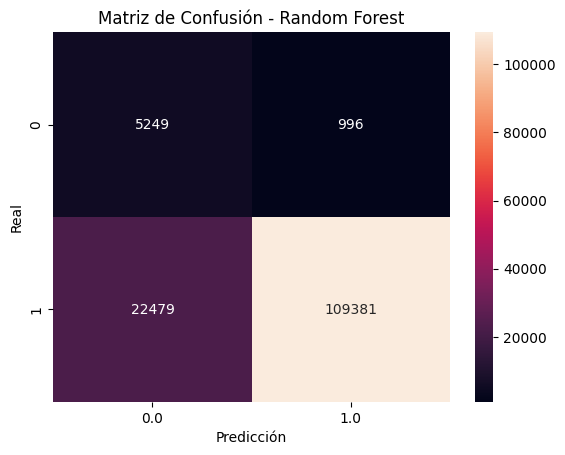

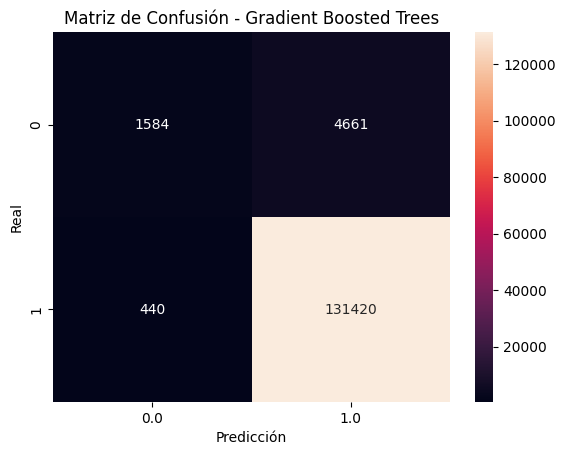

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# función para graficar la matriz de confusión
# recibe la tabla agrupada y el título del gráfico
def plot_confusion(cm, title):
    pivot = cm.pivot(index="label", columns="prediction", values="count").fillna(0)

    plt.figure()
    sns.heatmap(pivot, annot=True, fmt=".0f")
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

plot_confusion(cm_lr, "Matriz de Confusión - Logistic Regression")
plot_confusion(cm_rf, "Matriz de Confusión - Random Forest")
plot_confusion(cm_gbt, "Matriz de Confusión - Gradient Boosted Trees")


In [0]:
# revisamos la distribución del test
# esto ayuda a interpretar las matrices de confusión
df_test.groupBy("label").count().display()


label,count
1,131860
0,6245


## Paso 9. Curva roc comparativa

La curva roc permite comparar la capacidad de separación de los modelos. mientras más cerca esté la curva de la esquina superior izquierda mejor.


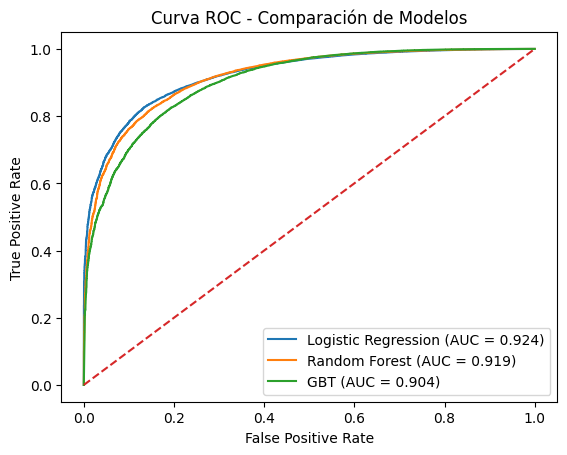

In [0]:
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# tomamos la probabilidad de clase 1 para regresión logística
lr_scores = lr_pred.select(
    "label",
    vector_to_array("probability")[1].alias("prob")
)
pdf_lr = lr_scores.toPandas()
fpr_lr, tpr_lr, _ = roc_curve(pdf_lr["label"], pdf_lr["prob"])
auc_lr = auc(fpr_lr, tpr_lr)

# hacemos lo mismo para random forest
rf_scores = rf_pred.select(
    "label",
    vector_to_array("probability")[1].alias("prob")
)
pdf_rf = rf_scores.toPandas()
fpr_rf, tpr_rf, _ = roc_curve(pdf_rf["label"], pdf_rf["prob"])
auc_rf = auc(fpr_rf, tpr_rf)

# y también para gbt
gbt_scores = gbt_pred.select(
    "label",
    vector_to_array("probability")[1].alias("prob")
)
pdf_gbt = gbt_scores.toPandas()
fpr_gbt, tpr_gbt, _ = roc_curve(pdf_gbt["label"], pdf_gbt["prob"])
auc_gbt = auc(fpr_gbt, tpr_gbt)

# gráfico comparativo de las tres curvas
plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_gbt, tpr_gbt, label=f"GBT (AUC = {auc_gbt:.3f})")

# línea base de un clasificador aleatorio
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación de Modelos")
plt.legend()
plt.show()
